In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import read_intensities, read_unique_kmer_positions


# (optional) nicer labels without scientific notation spam
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

/home/aki/miniconda3/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Fig 2 

In [5]:
PI_FOXA1_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_FOXA1_MCF7_probeIntensity.bed"
PI_CTCF_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_CTCF_MCF7_Stam_probeIntensity.bed"
ARRAY_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/array/MCF7_Array_8mer_DNase.txt"

In [6]:
foxa1 = read_intensities(PI_FOXA1_MCF7)
ctcf  = read_intensities(PI_CTCF_MCF7)
kmers = read_unique_kmer_positions(ARRAY_MCF7)

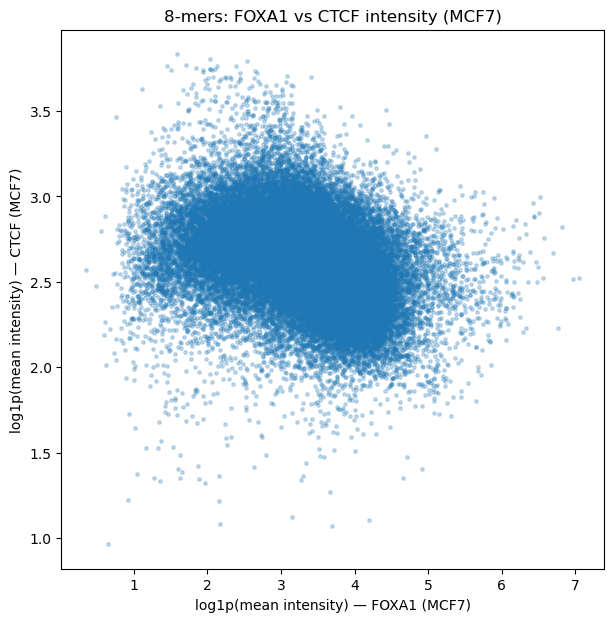

In [7]:
rows=[]
for k, r2o in kmers.items():
    regs = r2o.keys()
    x = [foxa1[r] for r in regs if r in foxa1]
    y = [ctcf[r]  for r in regs if r in ctcf]
    if x and y:
        rows.append((k, float(np.mean(x)), float(np.mean(y))))
df = pd.DataFrame(rows, columns=["kmer","foxa1_mean","ctcf_mean"])

plt.figure(figsize=(7,7))
plt.scatter(np.log1p(df["foxa1_mean"]), np.log1p(df["ctcf_mean"]), s=6, alpha=0.25)
plt.xlabel("log1p(mean intensity) — FOXA1 (MCF7)")
plt.ylabel("log1p(mean intensity) — CTCF (MCF7)")
plt.title("8-mers: FOXA1 vs CTCF intensity (MCF7)")
plt.show()

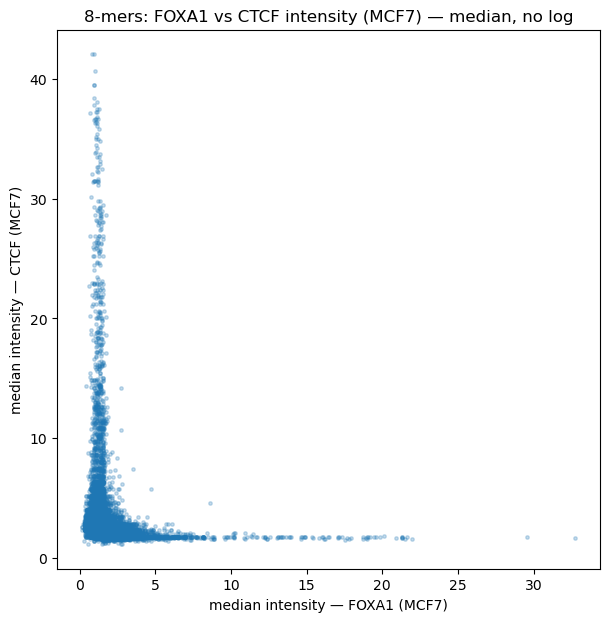

In [8]:
rows=[]
for k, r2o in kmers.items():
    regs = r2o.keys()
    x = [foxa1[r] for r in regs if r in foxa1]
    y = [ctcf[r]  for r in regs if r in ctcf]
    if x and y:
        rows.append((k, float(np.median(x)), float(np.median(y))))
df = pd.DataFrame(rows, columns=["kmer","foxa1_med","ctcf_med"])

plt.figure(figsize=(7,7))
plt.scatter(df["foxa1_med"], df["ctcf_med"], s=6, alpha=0.25)
plt.xlabel("median intensity — FOXA1 (MCF7)")
plt.ylabel("median intensity — CTCF (MCF7)")
plt.title("8-mers: FOXA1 vs CTCF intensity (MCF7) — median, no log")
plt.show()


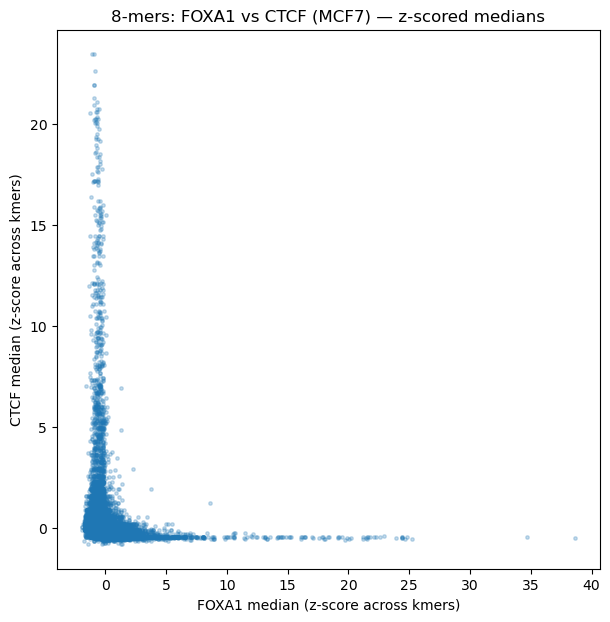

In [10]:
rows=[]
for k, r2o in kmers.items():
    regs = r2o.keys()
    x = [foxa1[r] for r in regs if r in foxa1]
    y = [ctcf[r]  for r in regs if r in ctcf]
    if x and y:
        rows.append((k, float(np.median(x)), float(np.median(y))))
df = pd.DataFrame(rows, columns=["kmer","foxa1_med","ctcf_med"])

# z-score within each TF across kmers
df["foxa1_z"] = (df["foxa1_med"] - df["foxa1_med"].mean()) / df["foxa1_med"].std()
df["ctcf_z"]  = (df["ctcf_med"]  - df["ctcf_med"].mean())  / df["ctcf_med"].std()

plt.figure(figsize=(7,7))
plt.scatter(df["foxa1_z"], df["ctcf_z"], s=6, alpha=0.25)
plt.xlabel("FOXA1 median (z-score across kmers)")
plt.ylabel("CTCF median (z-score across kmers)")
plt.title("8-mers: FOXA1 vs CTCF (MCF7) — z-scored medians")
plt.show()



## GABPA vs FOXA1 MCF7

In [2]:
PI_FOXA1_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_FOXA1_MCF7_probeIntensity.bed"
PI_GABPA_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_GABPA_MCF7_ENCFF835KCG_probeIntensity.bed"
ARRAY_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/array/MCF7_Array_8mer_DNase.txt"

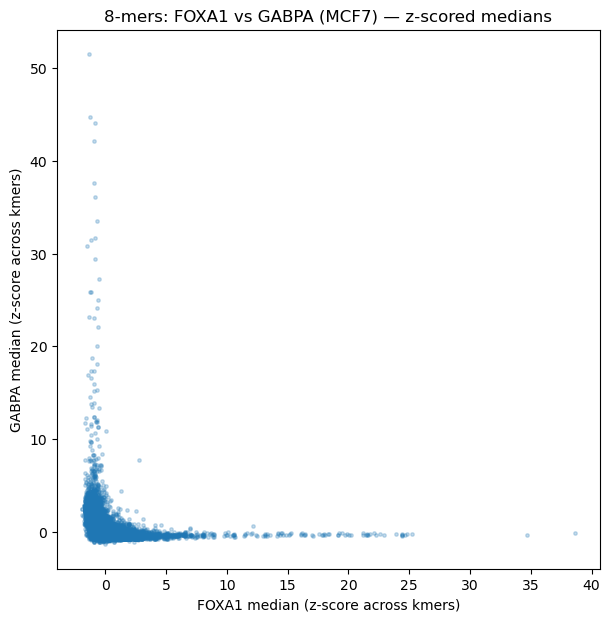

In [3]:
foxa1 = read_intensities(PI_FOXA1_MCF7)
gabpa = read_intensities(PI_GABPA_MCF7)
kmers = read_unique_kmer_positions(ARRAY_MCF7)

rows=[]
for k, r2o in kmers.items():
    regs = r2o.keys()
    x = [foxa1[r] for r in regs if r in foxa1]
    y = [gabpa[r] for r in regs if r in gabpa]
    if x and y:
        rows.append((k, float(np.median(x)), float(np.median(y))))
df = pd.DataFrame(rows, columns=["kmer","foxa1_med","gabpa_med"])

df["foxa1_z"] = (df["foxa1_med"] - df["foxa1_med"].mean()) / df["foxa1_med"].std()
df["gabpa_z"] = (df["gabpa_med"] - df["gabpa_med"].mean()) / df["gabpa_med"].std()

plt.figure(figsize=(7,7))
plt.scatter(df["foxa1_z"], df["gabpa_z"], s=6, alpha=0.25)
plt.xlabel("FOXA1 median (z-score across kmers)")
plt.ylabel("GABPA median (z-score across kmers)")
plt.title("8-mers: FOXA1 vs GABPA (MCF7) — z-scored medians")
plt.show()

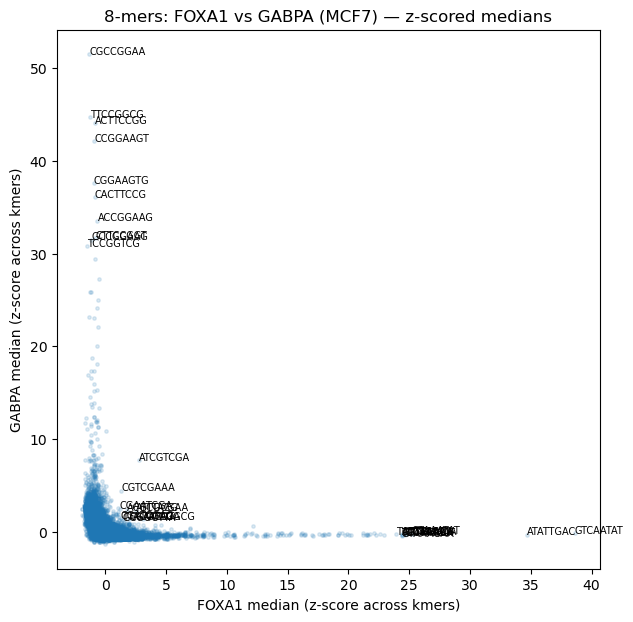

In [4]:
plt.figure(figsize=(7,7))
plt.scatter(df["foxa1_z"], df["gabpa_z"], s=6, alpha=0.15)
plt.xlabel("FOXA1 median (z-score across kmers)")
plt.ylabel("GABPA median (z-score across kmers)")
plt.title("8-mers: FOXA1 vs GABPA (MCF7) — z-scored medians")

# pick kmers to label
n = 10
gabpa_top = df.nlargest(n, "gabpa_z")
foxa1_top = df.nlargest(n, "foxa1_z")
shared_top = df.assign(shared=np.minimum(df["foxa1_z"], df["gabpa_z"])).nlargest(n, "shared")

to_label = pd.concat([gabpa_top, foxa1_top, shared_top]).drop_duplicates("kmer")

for _, r in to_label.iterrows():
    plt.text(r["foxa1_z"], r["gabpa_z"], r["kmer"], fontsize=7)

plt.show()


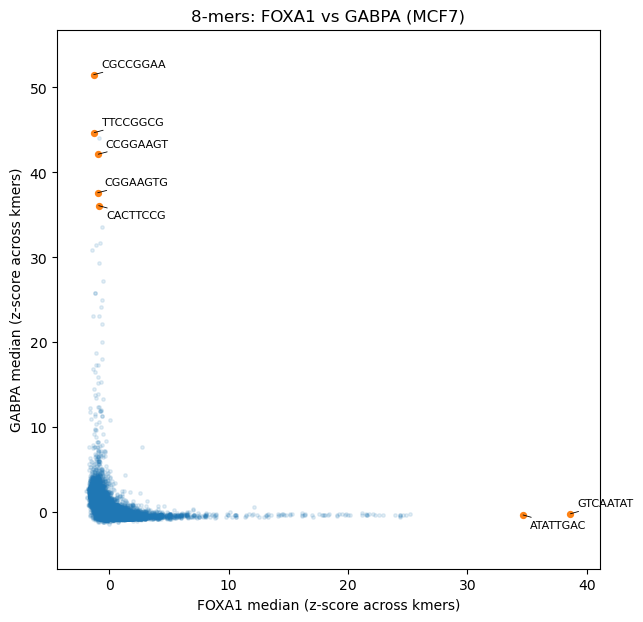

In [15]:
# ---- settings ----
x_thr = 6
y_thr = 6
max_labels = 7
min_dist = 1.5   # increase this so we do not pick points that are too close to label cleanly
fontsize = 8

# ---- pick tail points (spaced apart in point-space) ----
tail = df[(df["foxa1_z"] >= x_thr) | (df["gabpa_z"] >= y_thr)].copy()
tail["priority"] = np.maximum(tail["foxa1_z"], tail["gabpa_z"])
tail = tail.sort_values("priority", ascending=False)

chosen_xy, chosen_rows = [], []
for _, r in tail.iterrows():
    x, y = r["foxa1_z"], r["gabpa_z"]
    if all((x-cx)**2 + (y-cy)**2 >= min_dist**2 for cx, cy in chosen_xy):
        chosen_xy.append((x, y))
        chosen_rows.append(r)
        if len(chosen_rows) >= max_labels:
            break
label_df = pd.DataFrame(chosen_rows)

# ---- plot ----
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(df["foxa1_z"], df["gabpa_z"], s=6, alpha=0.12)
ax.scatter(label_df["foxa1_z"], label_df["gabpa_z"], s=18, alpha=0.95)

ax.set_xlabel("FOXA1 median (z-score across kmers)")
ax.set_ylabel("GABPA median (z-score across kmers)")
ax.set_title("8-mers: FOXA1 vs GABPA (MCF7)")
ax.margins(x=0.06, y=0.10)

# ---- non-overlapping label placement (tries many positions; keeps all if possible) ----
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
placed = []

dirs = [(1,1),(1,-1),(-1,1),(-1,-1),(1,0),(-1,0),(0,1),(0,-1)]
radii = [0.6, 1.0, 1.6, 2.4, 3.2, 4.0]  # in data units (z-space)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

for _, r in label_df.iterrows():
    x, y, t = r["foxa1_z"], r["gabpa_z"], r["kmer"]
    placed_ok = False

    for rad in radii:
        for sx, sy in dirs:
            dx, dy = sx*rad, sy*rad
            xt, yt = x + dx, y + dy

            # keep label inside axes
            if not (xlim[0] <= xt <= xlim[1] and ylim[0] <= yt <= ylim[1]):
                continue

            ha = "left" if sx > 0 else ("right" if sx < 0 else "center")
            va = "bottom" if sy > 0 else ("top" if sy < 0 else "center")

            ann = ax.annotate(
                t,
                xy=(x, y),
                xytext=(xt, yt),
                textcoords="data",
                ha=ha, va=va,
                fontsize=fontsize,
                arrowprops=dict(arrowstyle="-", lw=0.6, shrinkA=0, shrinkB=0),
            )

            fig.canvas.draw()
            bb = ann.get_window_extent(renderer=renderer)

            if any(bb.overlaps(prev) for prev in placed):
                ann.remove()
                continue

            placed.append(bb)
            placed_ok = True
            break
        if placed_ok:
            break

    # fallback: if we truly can't place it without overlap, still show it (furthest up-right)
    if not placed_ok:
        ax.annotate(
            t, xy=(x, y), xytext=(x+4.5, y+4.5), textcoords="data",
            ha="left", va="bottom", fontsize=fontsize,
            arrowprops=dict(arrowstyle="-", lw=0.6, shrinkA=0, shrinkB=0),
        )

plt.show()


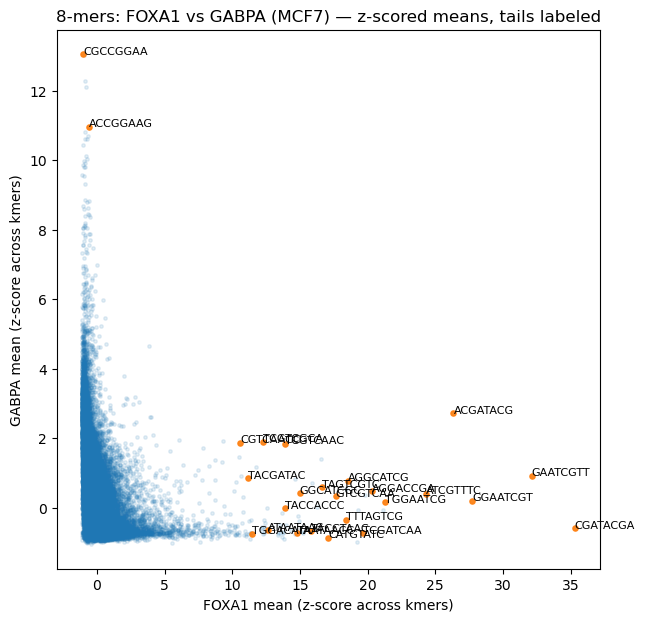

In [10]:
# --- mean version (z-scored means + tail labels, no overlaps) ---
rows=[]
for k, r2o in kmers.items():
    regs = r2o.keys()
    x = [foxa1[r] for r in regs if r in foxa1]
    y = [gabpa[r] for r in regs if r in gabpa]
    if x and y:
        rows.append((k, float(np.mean(x)), float(np.mean(y))))
dfm = pd.DataFrame(rows, columns=["kmer","foxa1_mean","gabpa_mean"])

dfm["foxa1_z"] = (dfm["foxa1_mean"] - dfm["foxa1_mean"].mean()) / dfm["foxa1_mean"].std()
dfm["gabpa_z"] = (dfm["gabpa_mean"] - dfm["gabpa_mean"].mean()) / dfm["gabpa_mean"].std()

# tail label settings (tweak)
x_thr, y_thr = 6, 6
max_labels = 25
min_dist = 1.0

tail = dfm[(dfm["foxa1_z"] >= x_thr) | (dfm["gabpa_z"] >= y_thr)].copy()
tail["priority"] = np.maximum(tail["foxa1_z"], tail["gabpa_z"])
tail = tail.sort_values("priority", ascending=False)

chosen = []
keep = []
for _, r in tail.iterrows():
    x, y = r["foxa1_z"], r["gabpa_z"]
    if all((x-cx)**2 + (y-cy)**2 >= min_dist**2 for cx, cy in chosen):
        chosen.append((x, y))
        keep.append(True)
        if len(chosen) >= max_labels:
            break
    else:
        keep.append(False)

label_df = tail.iloc[:len(keep)][keep]

plt.figure(figsize=(7,7))
plt.scatter(dfm["foxa1_z"], dfm["gabpa_z"], s=6, alpha=0.12)
plt.scatter(label_df["foxa1_z"], label_df["gabpa_z"], s=14, alpha=0.9)

for _, r in label_df.iterrows():
    plt.text(r["foxa1_z"], r["gabpa_z"], r["kmer"], fontsize=8)

plt.xlabel("FOXA1 mean (z-score across kmers)")
plt.ylabel("GABPA mean (z-score across kmers)")
plt.title("8-mers: FOXA1 vs GABPA (MCF7) — z-scored means, tails labeled")
plt.show()


# Fig 3

In [2]:
PI_FOXA1_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_FOXA1_MCF7_probeIntensity.bed"
PI_FOXA1_HEPG2="/mnt/c/Users/Aki/Desktop/EUBAR/data/intensities/DNase_FOXA1_HepG2_probeIntensity.bed"
ARRAY_MCF7="/mnt/c/Users/Aki/Desktop/EUBAR/data/array/MCF7_Array_8mer_DNase.txt"
ARRAY_HEPG2="/mnt/c/Users/Aki/Desktop/EUBAR/data/array/HepG2_DNase_8mer_Array.txt"

mcf7_int = read_intensities(PI_FOXA1_MCF7)
hepg2_int = read_intensities(PI_FOXA1_HEPG2)

mcf7_kmers = read_unique_kmer_positions(ARRAY_MCF7)
hepg2_kmers = read_unique_kmer_positions(ARRAY_HEPG2)

len(mcf7_int), len(hepg2_int), len(mcf7_kmers), len(hepg2_kmers)

(155128, 130520, 65536, 65536)

In [3]:
def kmer_stats(kmer_map, intensities):
    out = {}
    for kmer, region2off in kmer_map.items():
        vals = [intensities[r] for r in region2off.keys() if r in intensities]
        if len(vals) == 0:
            continue
        out[kmer] = (float(np.mean(vals)), float(np.median(vals)), len(vals))
    return out

mcf7_stats = kmer_stats(mcf7_kmers, mcf7_int)  # kmer -> (mean, median, n)
hepg2_stats = kmer_stats(hepg2_kmers, hepg2_int)

# keep only kmers present in both (should basically be all 8-mers)
common = sorted(set(mcf7_stats) & set(hepg2_stats))
len(common)


65536

In [4]:
rows = []
for k in common:
    m_mean, m_med, m_n = mcf7_stats[k]
    k_mean, k_med, k_n = hepg2_stats[k]
    rows.append({
        "kmer": k,
        "mcf7_mean": m_mean,
        "hepg2_mean": k_mean,
        "mcf7_median": m_med,
        "hepg2_median": k_med,
        "mcf7_n": m_n,
        "hepg2_n": k_n,
    })

df_fx = pd.DataFrame(rows)
df_fx.shape, df_fx.head()


((65536, 7),
        kmer  mcf7_mean  hepg2_mean  mcf7_median  hepg2_median  mcf7_n  hepg2_n
 0  AAAAAAAA  34.465912    4.736374      1.98080       0.88144     911      778
 1  AAAAAAAC  52.979016    9.232434      2.13374       0.92522    1301     1154
 2  AAAAAAAG  38.731584    4.649141      1.83675       0.91759    1990     1959
 3  AAAAAAAT  33.054152    4.725048      1.69813       0.81028    2043     1751
 4  AAAAAACA  38.612903    9.704082      2.37827       0.96641    1434     1260)

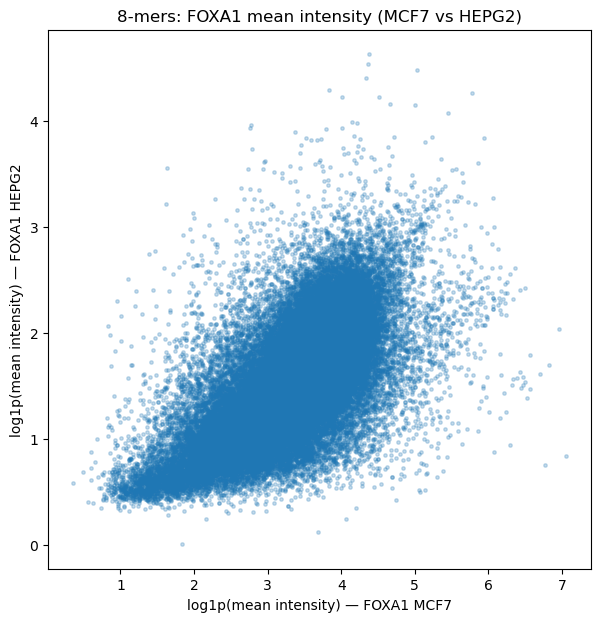

0.6417994540800327

In [5]:
x = np.log1p(df_fx["mcf7_mean"].values)
y = np.log1p(df_fx["hepg2_mean"].values)

plt.figure(figsize=(7,7))
plt.scatter(x, y, s=6, alpha=0.25)
plt.xlabel("log1p(mean intensity) — FOXA1 MCF7")
plt.ylabel("log1p(mean intensity) — FOXA1 HEPG2")
plt.title("8-mers: FOXA1 mean intensity (MCF7 vs HEPG2)")
plt.show()

# Spearman rank correlation (no scipy needed)
spearman = pd.Series(df_fx["mcf7_mean"]).rank().corr(pd.Series(df_fx["hepg2_mean"]).rank(), method="pearson")
spearman


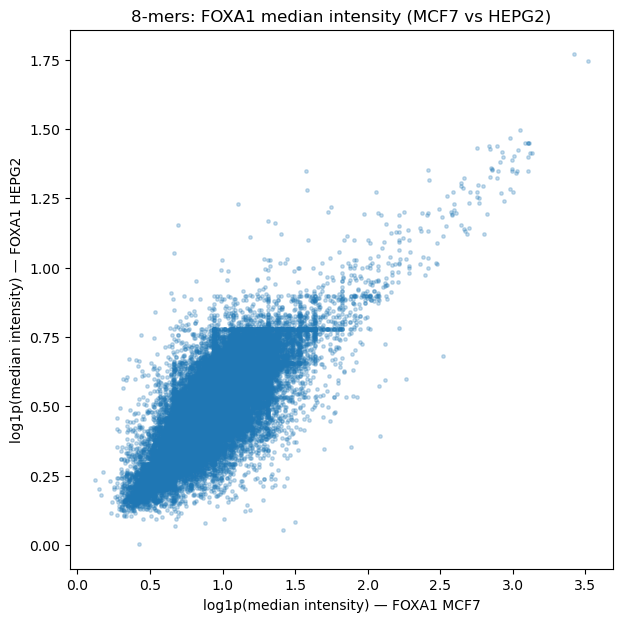

0.736278145769099

In [6]:
x = np.log1p(df_fx["mcf7_median"].values)
y = np.log1p(df_fx["hepg2_median"].values)

plt.figure(figsize=(7,7))
plt.scatter(x, y, s=6, alpha=0.25)
plt.xlabel("log1p(median intensity) — FOXA1 MCF7")
plt.ylabel("log1p(median intensity) — FOXA1 HEPG2")
plt.title("8-mers: FOXA1 median intensity (MCF7 vs HEPG2)")
plt.show()

# Spearman rank correlation (no scipy needed)
spearman = pd.Series(df_fx["mcf7_median"]).rank().corr(pd.Series(df_fx["hepg2_median"]).rank(), method="pearson")
spearman


In [7]:
topN = 200
top_m = set(df_fx.sort_values("mcf7_median", ascending=False).head(topN)["kmer"])
top_k = set(df_fx.sort_values("hepg2_median", ascending=False).head(topN)["kmer"])

overlap = len(top_m & top_k)
overlap, overlap / topN


(138, 0.69)

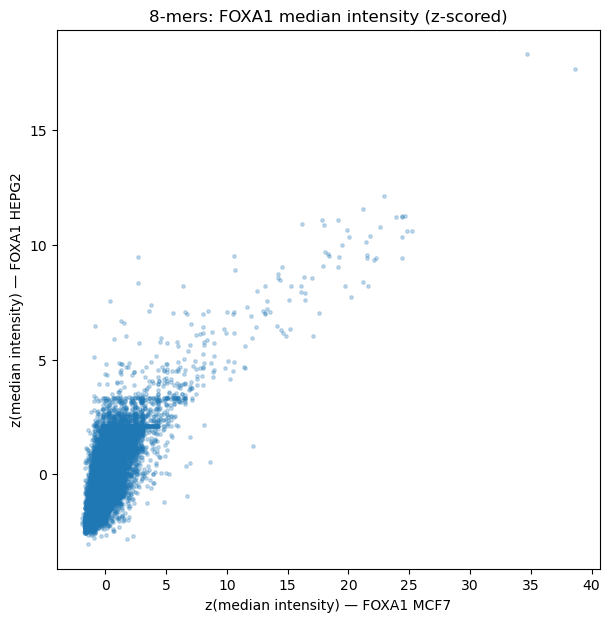

In [8]:
m = df_fx["mcf7_median"]
k = df_fx["hepg2_median"]

mz = (m - m.mean()) / m.std()
kz = (k - k.mean()) / k.std()

plt.figure(figsize=(7,7))
plt.scatter(mz, kz, s=6, alpha=0.25)
plt.xlabel("z(median intensity) — FOXA1 MCF7")
plt.ylabel("z(median intensity) — FOXA1 HEPG2")
plt.title("8-mers: FOXA1 median intensity (z-scored)")
plt.show()


In [9]:
tmp = df_fx.copy()

# percentile ranks (0..1) within each cell line
tmp["mcf7_pr"] = tmp["mcf7_mean"].rank(pct=True)
tmp["hepg2_pr"] = tmp["hepg2_mean"].rank(pct=True)

# "high in both" = whichever is lower (forces both to be high)
tmp["both_high"] = np.minimum(tmp["mcf7_pr"], tmp["hepg2_pr"])

top = tmp.sort_values("both_high", ascending=False).head(50)

top[["kmer", "mcf7_mean", "hepg2_mean", "mcf7_pr", "hepg2_pr", "both_high"]]

,kmer,mcf7_mean,hepg2_mean,mcf7_pr,hepg2_pr,both_high
6349,ACGATATC,378.778135,45.595387,0.998947,0.999664,0.998947
46131,GTCAATAT,346.921211,35.965360,0.998611,0.999268,0.998611
12140,AGTTCGTA,321.225447,70.076083,0.998352,0.999924,0.998352
56164,TCGTCGCA,426.323147,25.367510,0.999237,0.998123,0.998123
48113,GTGTTTAC,304.041094,24.351399,0.998062,0.997849,0.997849
...,...,...,...,...,...,...
61124,TGTGTACA,234.773915,17.866903,0.996750,0.993835,0.993835
35587,GAGTAAAT,175.633223,21.022688,0.993622,0.996582,0.993622
52944,TATGTCAA,174.174724,19.696115,0.993530,0.995621,0.993530
11532,AGTCAATA,173.772243,22.830726,0.993484,0.997345,0.993484


In [10]:
tmp = df_fx.copy()

tmp["mcf7_pr"] = tmp["mcf7_median"].rank(pct=True)
tmp["hepg2_pr"] = tmp["hepg2_median"].rank(pct=True)

tmp["both_high"] = np.minimum(tmp["mcf7_pr"], tmp["hepg2_pr"])

top_med = tmp.sort_values("both_high", ascending=False).head(50)

top_med[["kmer", "mcf7_median", "hepg2_median", "mcf7_pr", "hepg2_pr", "both_high"]]

,kmer,mcf7_median,hepg2_median,mcf7_pr,hepg2_pr,both_high
13281,ATATTGAC,29.542774,4.867390,0.999985,1.000000,0.999985
46131,GTCAATAT,32.730400,4.716340,1.000000,0.999985,0.999985
45075,GTAAACAT,21.473961,3.258670,0.999939,0.999939,0.999939
11268,AGTAAACA,21.269779,3.253830,0.999901,0.999901,0.999901
64497,TTGTTTAC,21.269779,3.256865,0.999901,0.999924,0.999901
...,...,...,...,...,...,...
53189,TATTTACC,13.078440,2.650070,0.999191,0.999413,0.999191
48659,GTTGACAT,13.823950,2.425370,0.999298,0.999184,0.999184
44044,GGTAAATA,14.860920,2.425370,0.999405,0.999184,0.999184
45105,GTAAATAC,12.359440,2.414535,0.999138,0.999146,0.999138
